In [1]:
# REquired Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

df = pd.read_csv('/content/Final_Master_Dataset.csv')
df.head()


,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,USA,1994,4.215265,NaN,NaN,NaN,19.83,364,0,0,263126000,4.029023,2.761109,7.290000e+12,2.607442,6.119,6.174,6.052
1,USA,1995,3.860246,NaN,NaN,NaN,19.79,243,0,0,266278000,2.684431,1.468929,7.640000e+12,2.805420,5.650,5.633,5.671
2,USA,1996,3.554982,NaN,NaN,NaN,20.14,141,0,0,269394000,3.772773,2.572464,8.070000e+12,2.931204,5.451,5.435,5.470
3,USA,1997,3.554982,NaN,NaN,NaN,20.90,75,0,0,272657000,4.447128,3.197166,8.580000e+12,2.337690,5.000,4.938,5.075
4,USA,1998,3.201558,NaN,NaN,NaN,20.83,50,0,0,275854000,4.483133,3.272230,9.060000e+12,1.552279,4.511,4.419,4.623


In [2]:
# Final Economic Dataset:
features = [
    "Country",
    "Year",
    "D_Expenditure_GDP",
    "GDP_Growth_Annual",
    "Inflation_Annual",
    "Unemployment_Total_of_TLF",
    "GDP_PerCapita_Growth_Annual",
    "GDP_Current_USDollars",
    "Population"
]

econ_df = df[features].copy()

econ_df.columns = [
    "Country",
    "Year",
    "Defense_GDP",
    "GDP_Growth",
    "Inflation",
    "Unemployment",
    "GDP_PC_Growth",
    "GDP_Current_USD",
    "Population"
]

# Sanity Checks:
econ_df.info()
econ_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          155 non-null    object 
 1   Year             155 non-null    int64  
 2   Defense_GDP      155 non-null    float64
 3   GDP_Growth       155 non-null    float64
 4   Inflation        155 non-null    float64
 5   Unemployment     155 non-null    float64
 6   GDP_PC_Growth    155 non-null    float64
 7   GDP_Current_USD  155 non-null    float64
 8   Population       155 non-null    int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 11.0+ KB


,Year,Defense_GDP,GDP_Growth,Inflation,Unemployment,GDP_PC_Growth,GDP_Current_USD,Population
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.550000e+02,1.550000e+02
mean,2009.000000,2.778980,3.366688,7.941282,6.446910,2.860431,5.783445e+12,3.806592e+08
std,8.973265,1.026659,4.090402,30.073988,2.494112,4.066489,6.634788e+12,4.838115e+08
min,1994.000000,1.605260,-12.569800,-1.401470,2.527000,-12.539800,1.960000e+11,5.786574e+07
25%,2001.000000,1.924853,1.673178,1.569155,4.560000,1.070603,1.565000e+12,6.521442e+07
50%,2009.000000,2.422716,2.714064,2.292840,5.558000,2.117365,2.680000e+12,1.446486e+08
75%,2017.000000,3.505406,5.307406,4.584113,8.199500,5.535516,8.865000e+12,3.254810e+08
max,2024.000000,7.052339,14.149990,307.722600,13.261000,13.555370,2.920000e+13,1.412360e+09


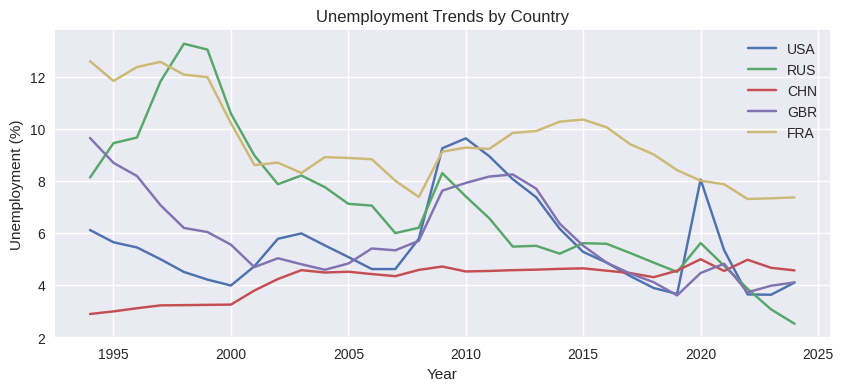

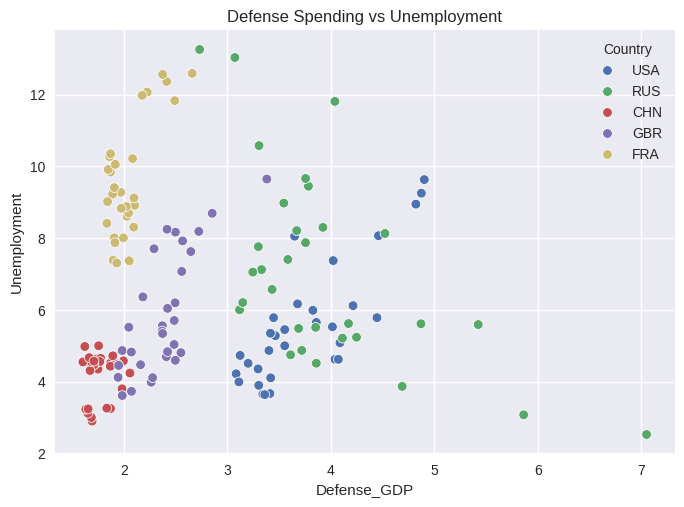

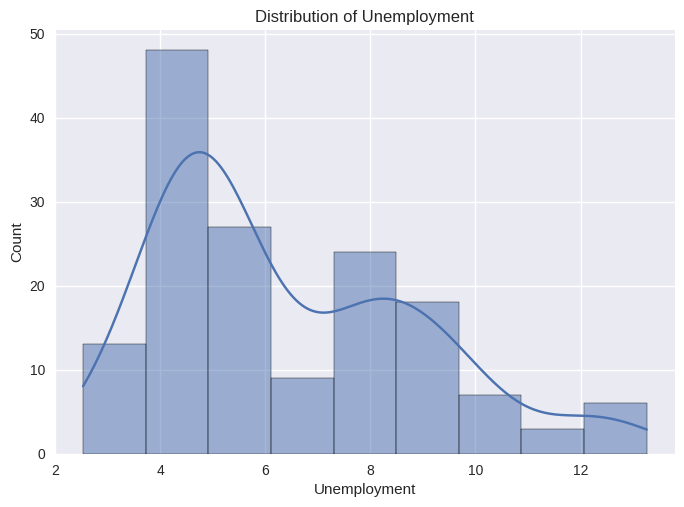

In [7]:
# Exploratory Data Analysis (EDA) For Unemployment Target:

# Trend by 'Country':
plt.figure(figsize=(10,4))
for c in econ_df["Country"].unique():
    cdf = econ_df[econ_df["Country"] == c]
    plt.plot(cdf["Year"], cdf["Unemployment"], label=c)

plt.title("Unemployment Trends by Country")
plt.xlabel("Year")
plt.ylabel("Unemployment (%)")
plt.legend()
plt.show()
print("\n")

# Defence Spending vs Unemployment:
sns.scatterplot(
    data=econ_df,
    x="Defense_GDP",
    y="Unemployment",
    hue="Country"
)
plt.title("Defense Spending vs Unemployment")
plt.show()
print("\n")

# Distribution:
sns.histplot(econ_df["Unemployment"], kde=True)
plt.title("Distribution of Unemployment")
plt.show()




In [8]:
# Encode 'Country' Feature:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
econ_df["Country_ID"] = le.fit_transform(econ_df["Country"])

# Create Lag Features:
econ_df["Unemp_lag1"] = econ_df.groupby("Country")["Unemployment"].shift(1)
econ_df["Unemp_lag2"] = econ_df.groupby("Country")["Unemployment"].shift(2)

# Drop NaNs From Lags:
econ_df = econ_df.dropna().reset_index(drop=True)

INPUT_FEATURES = [
    "Country_ID",
    "Defense_GDP",
    "GDP_PC_Growth",
    "GDP_Current_USD",
    "Population",
    "Unemp_lag1",
    "Unemp_lag2"
]

TARGET = "Unemployment"

# Train/Test Splits (Time-Based):
train_df = econ_df[econ_df["Year"] <= 2020]
test_df  = econ_df[(econ_df["Year"] >= 2021) & (econ_df["Year"] <= 2024)]

# Scaling:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = X_scaler.fit_transform(train_df[INPUT_FEATURES])
X_test  = X_scaler.transform(test_df[INPUT_FEATURES])

y_train = y_scaler.fit_transform(train_df[[TARGET]])
y_test  = y_scaler.transform(test_df[[TARGET]])

# Create LSTM Sequences:
TIME_STEPS = 5

def create_sequences(X, y, steps):
    Xs, ys = [], []
    for i in range(len(X) - steps):
        Xs.append(X[i:i+steps])
        ys.append(y[i+steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)


In [9]:
# LSTM Model:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(TIME_STEPS, X_train_seq.shape[2])),
    LSTM(16),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.1284 - val_loss: 0.1926
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0632 - val_loss: 0.0955
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0658 - val_loss: 0.0734
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0510 - val_loss: 0.0901
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0490 - val_loss: 0.0924
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0539 - val_loss: 0.0792
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0471 - val_loss: 0.0658
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0403 - val_loss: 0.0545
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0429 - val_loss: 0.0568
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0442 - val_loss: 0.0551
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0415 - val_loss: 0.0547
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0461 - val_loss: 0.0418
Epoch 13/50


In [10]:
# Evaluation Part:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test_seq)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_seq)

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
MAE: 2.2093685450236005
RMSE: 3.050799834814323
R²: -2.515278840493484
